In [1]:
from config import client
import pandas as pd

In [2]:
customers_query = """
SELECT * FROM zoho_books_analytics.customers
"""

result = client.query(customers_query)

customers_df = pd.DataFrame(result.result_rows, columns=[col for col in result.column_names])

In [3]:
customers_df.head()

,customer_id,customer_name,display_name,email,phone,status,crm_reference_id,company_name,salutation,first_name,...,test,customer_number,commission_company,credit_insurance,sales_manager,customer_owner_id,default_address_id,pricelist_id,apn_codeid,testid
0,1410873000000183717,ABC Supermarket,ABC Supermarket,,(714) 379-6161,Active,3371443000002699805,,,,...,,CUS-1,,,,,1410873000003435913,1410873000000011001,,
1,1410873000000183729,"ALCHEMY SIMYA, INC.","ALCHEMY SIMYA, INC.",,,Active,3371443000002699806,,,,...,,CUS-2,,,,,1410873000000183736,1410873000000011001,,
2,1410873000000183741,"Aldi, Inc.","Aldi, Inc.",,706-387-7700,Active,3371443000002699807,,,,...,,CUS-3,,,,,1410873000066553307,1410873000000011001,,
3,1410873000000183753,Amende & Schultz Inc,Amende & Schultz Inc,,(323) 682-3806,Active,3371443000002699808,,,,...,,CUS-4,,,,,1410873000000879416,1410873000000011001,,
4,1410873000000183765,"Anderson Seafoods, Inc.","Anderson Seafoods, Inc.",gina@andersonseafoods.com,,Active,3371443000002699809,,,,...,,CUS-5,,,,,1410873000035218643,1410873000000011001,,


In [4]:
customers_df.columns

Index(['customer_id', 'customer_name', 'display_name', 'email', 'phone',
       'status', 'crm_reference_id', 'company_name', 'salutation',
       'first_name', 'last_name', 'mobile_phone', 'payment_terms',
       'currency_code', 'notes', 'website', 'last_modified_time', 'source',
       'created_time', 'created_by', 'qb_id', 'marked_as_completed',
       'credit_limit', 'customer_sub_type', 'bank_account_payment',
       'customer_category', 'sales_category', 'push_to_crm', 'portal_enabled',
       'modified_by', 'sales_person', 'apn_code', 'test', 'customer_number',
       'commission_company', 'credit_insurance', 'sales_manager',
       'customer_owner_id', 'default_address_id', 'pricelist_id', 'apn_codeid',
       'testid'],
      dtype='object')

In [5]:
columns_to_drop = ['customer_id','display_name','company_name','email','phone','crm_reference_id','salutation','first_name','last_name','mobile_phone','notes','website','marked_as_completed','push_to_crm','portal_enabled','modified_by','apn_code','test','customer_number','customer_owner_id','default_address_id','pricelist_id','apn_codeid','testid','currency_code','bank_account_payment','source','qb_id','commission_company','sales_manager']
customers_df = customers_df.drop(columns=columns_to_drop)

In [6]:
customers_df[['credit_insurance','customer_name']].value_counts()

credit_insurance  customer_name                     
                  INSTITUTION FOOD HOUSE, INC           2
                  NORTHERN-HASEROT COMPANY              2
                  ZF America                            2
                  Seattle Shrimp and Seafood Company    1
                  Sea Rage Imports, Inc                 1
                                                       ..
                  KING WHOLESALE                        1
                  KK Film Networks                      1
                  KOT Wholesale                         1
                  KX Seafood Brokers, LLC               1
500000            Conexus Food Solutions                1
Name: count, Length: 709, dtype: int64

In [7]:
customers_df['credit_limit'] = customers_df['credit_limit'].str.replace('USD', '').str.strip()

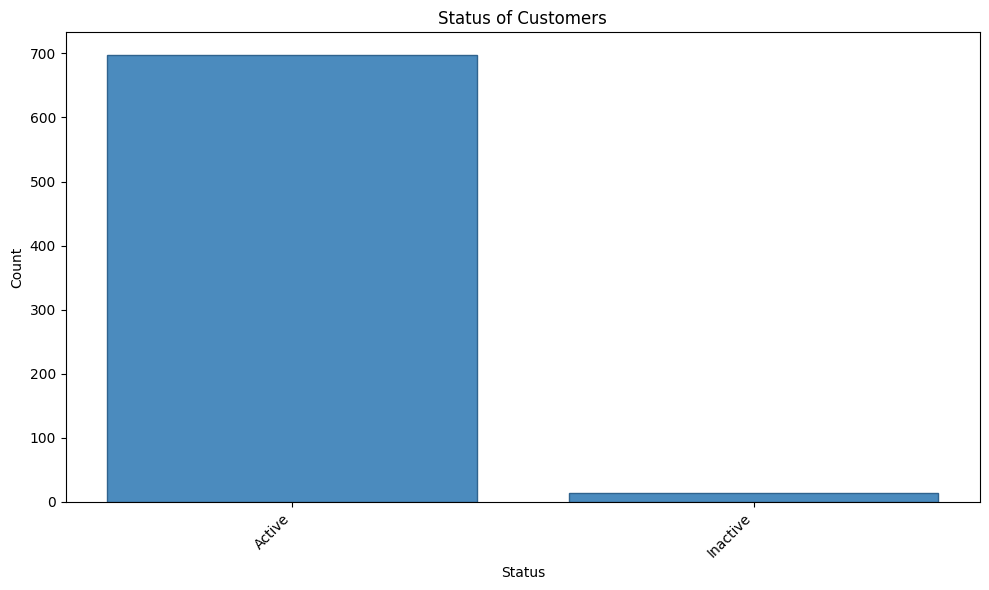

In [8]:
from graph import plot_bar_graph
plot_bar_graph(customers_df['status'], title="Status of Customers", x_label="Status", y_label="Count")

In [10]:
# plot_bar_graph(customers_df['currency_code'], title="Currency of Customers", x_label="Currency", y_label="Count")

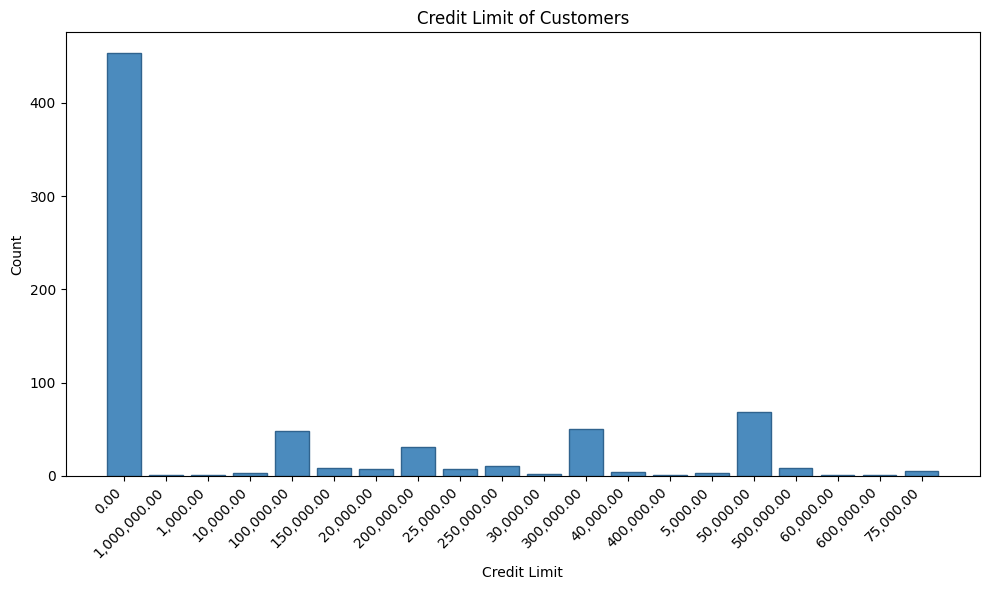

In [11]:
plot_bar_graph(customers_df['credit_limit'], title="Credit Limit of Customers", x_label="Credit Limit", y_label="Count")

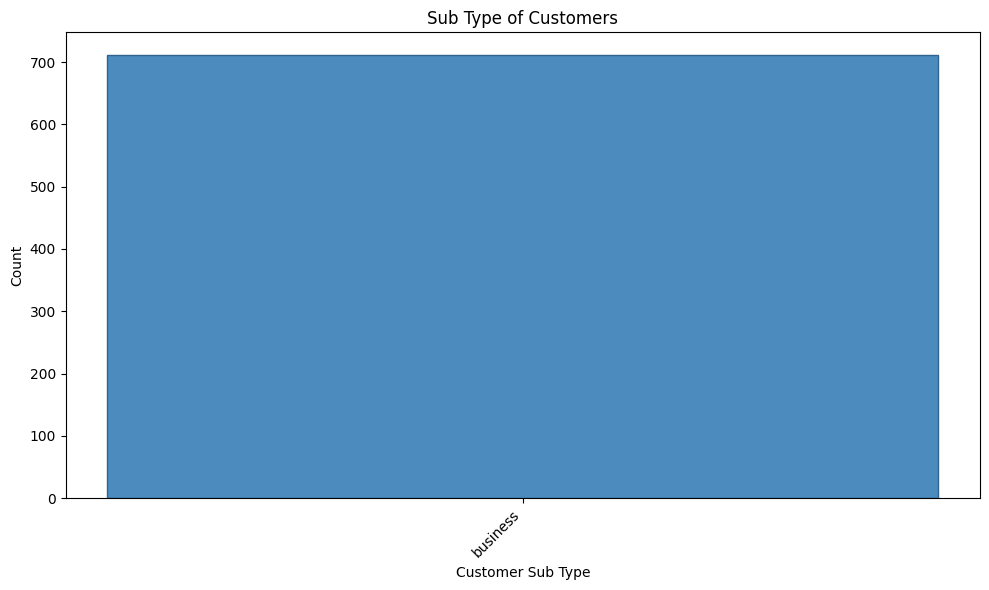

In [12]:
plot_bar_graph(customers_df['customer_sub_type'], title="Sub Type of Customers", x_label="Customer Sub Type", y_label="Count")

In [18]:
# plot_bar_graph(customers_df['bank_account_payment'], title="Bank Account Payment of Customers", x_label="Bank Account Payment", y_label="Count")

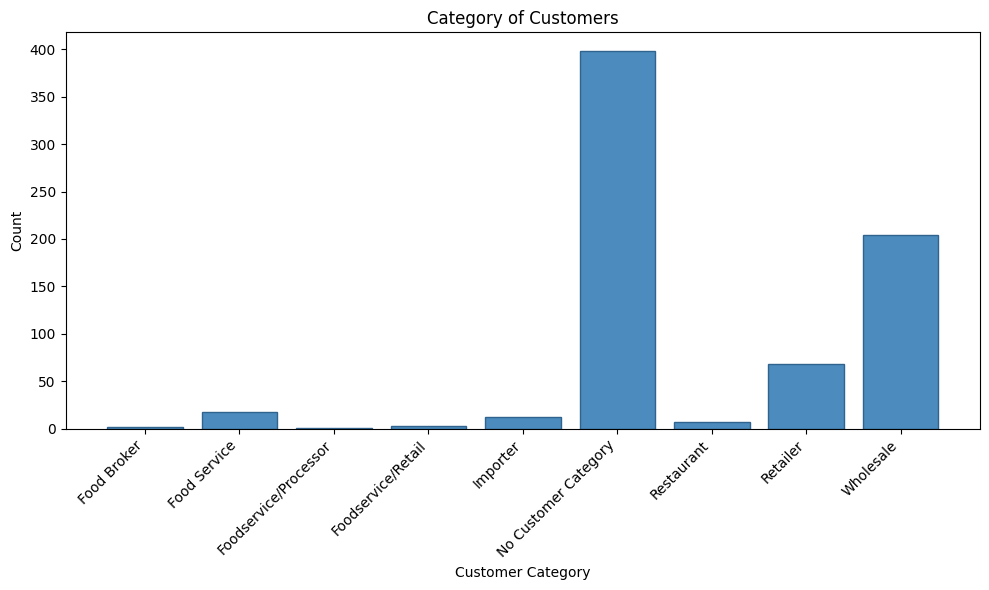

In [19]:
customers_df['customer_category'] = customers_df['customer_category'].replace('', 'No Customer Category')
plot_bar_graph(customers_df['customer_category'], title="Category of Customers", x_label="Customer Category", y_label="Count")

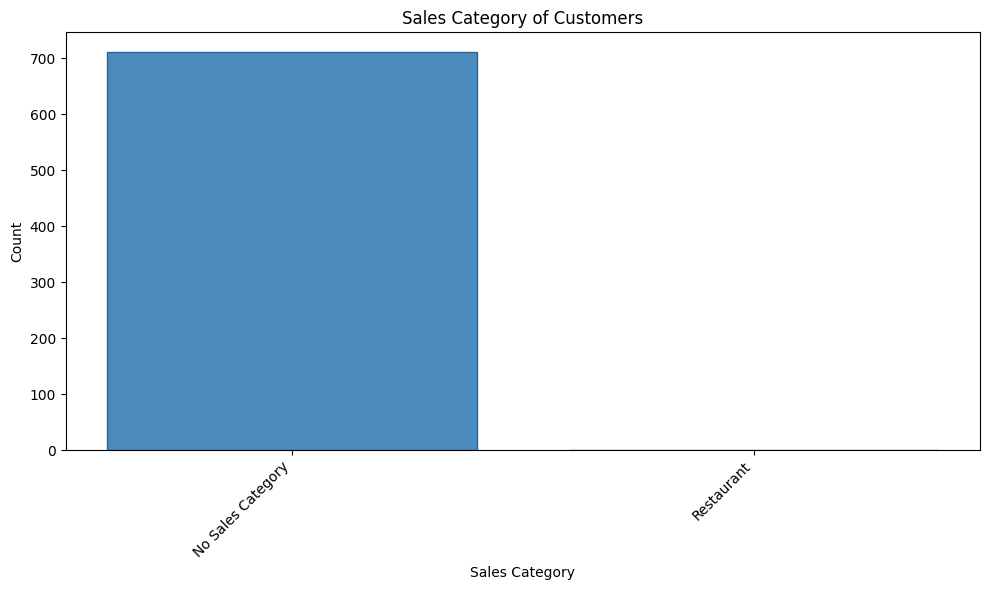

In [20]:
customers_df['sales_category'] = customers_df['sales_category'].replace('', 'No Sales Category')
plot_bar_graph(customers_df['sales_category'], title="Sales Category of Customers", x_label="Sales Category", y_label="Count")

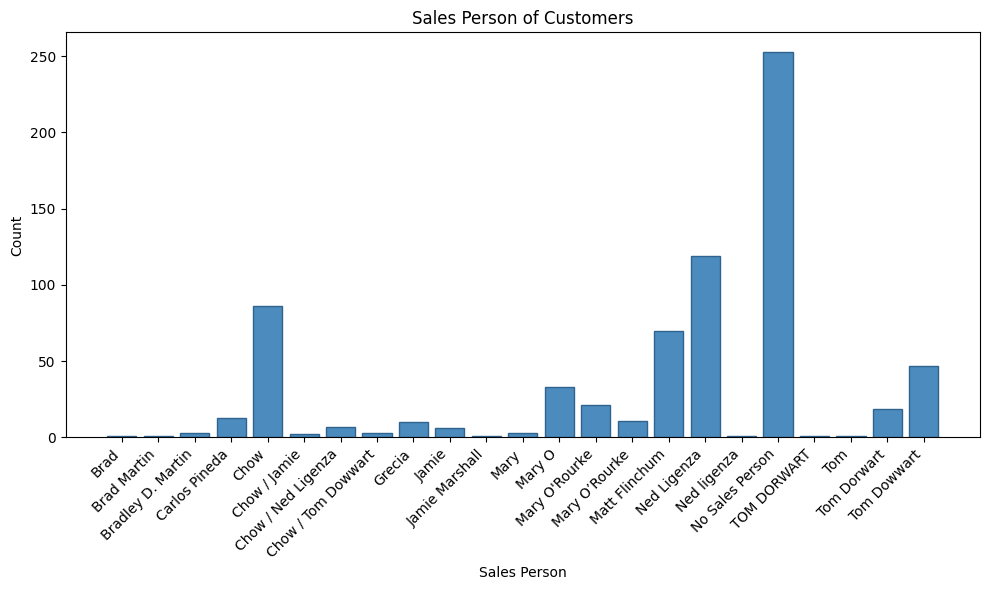

In [21]:
customers_df['sales_person'] = customers_df['sales_person'].replace('', 'No Sales Person')
plot_bar_graph(customers_df['sales_person'], title="Sales Person of Customers", x_label="Sales Person", y_label="Count")

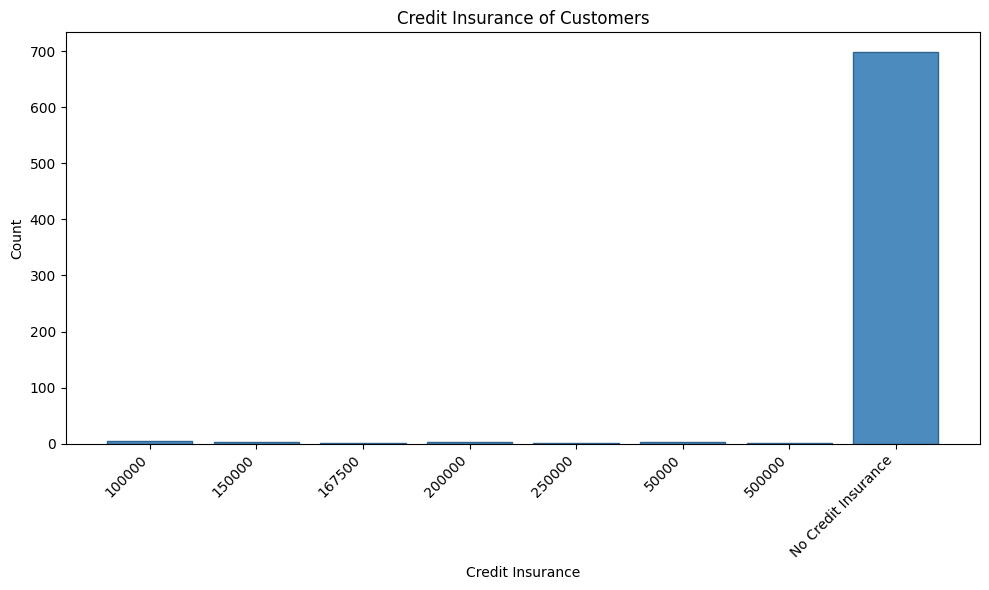

In [22]:
customers_df['credit_insurance'] = customers_df['credit_insurance'].replace('', 'No Credit Insurance')
plot_bar_graph(customers_df['credit_insurance'], title="Credit Insurance of Customers", x_label="Credit Insurance", y_label="Count")